In [ ]:
import os


In [117]:
from langchain.callbacks.base import BaseCallbackHandler
class CustomCallbackHandler(BaseCallbackHandler):
    def on_llm_start(self, serialized, prompts, **kwargs):
        print("\n--- 送信するテキスト ---")
        for i, prompt in enumerate(prompts):
            print(f"Prompt {i + 1}: {prompt}")
        print("\n")

    def on_llm_end(self, response, **kwargs):
        print("\n--- LLMからのレスポンス ---")
        print(response)
        print("\n")

In [177]:
from langchain_openai import ChatOpenAI 
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, List
from typing import Literal
from typing_extensions import TypedDict 
from langchain_core.tools import tool


class State(TypedDict):
    messages: Annotated[list, add_messages]


@tool
def fake_database_api(input_data: Annotated[str, "search word for partial-math retrieval"]) -> str:
    """API for searching personal information"""
    return "Tenma's favorite food is Ramen"

@tool 
def add(a : int, b : int) -> int : 
    """You need this when you want to add a and b""" 
    return a + b 

@tool 
def sub(a: int, b: int) -> int:
    """"You need this when you want to sub b from a"""
    return a -b 

@tool 
def multiply(a: int, b : int) -> int: 
    """You need this when you want to multiply a and b""" 
    return a * b





custom_handler = CustomCallbackHandler()
llm = ChatOpenAI(model="gpt-4o-mini", callbacks=[custom_handler], verbose="True")
llm_with_tool = llm.bind_tools([fake_database_api, add,sub,multiply])
tool_map = {
    "fake_database_api" : fake_database_api, 
    "add" : add, 
    "sub" : sub,
    "multiply" : multiply
}

In [178]:
from langchain_core.messages import ToolMessage



def agent(state: State) -> State:
    
    llm_res = llm_with_tool.invoke(state["messages"])
    state["messages"].append(llm_res)
    return state  # 非同期呼び出し


def tool_node(state: State) -> State:
    last_state = state["messages"][-1]
    tool_function = tool_map[last_state.tool_calls[0]["name"]]
    tool_output =  tool_function.invoke(last_state.tool_calls[0]["args"])  # 非同期呼び出し
    state["messages"].append(ToolMessage(content=tool_output, tool_call_id=last_state.tool_calls[0]["id"]))
    return state

def router(state: State) -> ["tool_node", END]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    else:
        return END
    
    

In [179]:
graph_builder = StateGraph(State)

graph_builder.add_node("agent",agent)
graph_builder.add_node("tool_node", tool_node)

graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges("agent", router)
graph_builder.add_edge("agent", END)

runner = graph_builder.compile()


In [180]:
input_state = State({"messages": ["what is 5 multiplied by 4 "]})
res= await runner.ainvoke(input_state)


--- 送信するテキスト ---
Prompt 1: Human: what is 5 multiplied by 4 



--- LLMからのレスポンス ---
generations=[[ChatGeneration(generation_info={'finish_reason': 'tool_calls', 'logprobs': None}, message=AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_Is40Ko1kQUgSre1fMscay2QY', 'function': {'arguments': '{"a":5,"b":4}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 151, 'total_tokens': 168, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_bba3c8e70b', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-d34e5a48-3f3f-42de-97d3-190e4d29912b-0', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 4}, 'id': 'call_Is40Ko1kQUgSre1fMscay2QY', 'type': 'tool_call'}], usa

In [183]:
res["messages"][-1]

ToolMessage(content='20', id='b95af597-76f5-40e8-8301-e78af92d3c9c', tool_call_id='call_Is40Ko1kQUgSre1fMscay2QY')

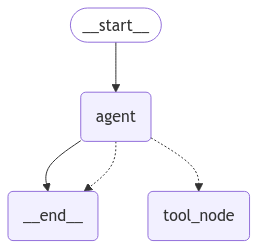

In [182]:
from IPython.display import display, Image


display(Image(runner.get_graph().draw_mermaid_png()))

# Try Spatial LLM With Fake Functions

In [9]:
from langchain.callbacks.base import BaseCallbackHandler

class CustomCallbackHandler(BaseCallbackHandler):
    def on_llm_start(self, serialized, prompts, **kwargs):
        print("\n--- 送信するテキスト ---")
        for i, prompt in enumerate(prompts):
            print(f"Prompt {i + 1}: {prompt}")
        print("\n")

    def on_llm_end(self, response, **kwargs):
        print("\n--- LLMからのレスポンス ---")
        print(response)
        print("\n")

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages
from typing import List
from dataclasses import dataclass
from langchain.tools import tool
from typing import Annotated, List
from typing_extensions import TypedDict 
from IPython.display import display, Image
from typing import Dict
import httpx

import os 

custom_handler = CustomCallbackHandler()
llm = ChatOpenAI(model="gpt-4o-mini", callbacks=[custom_handler], verbose="True")
mr_server_url = "http://localhost:7070"

In [39]:


@dataclass
class DeviceData:
    def __init__(self, device_name: str, device_id: str, distance: float):
        self.device_name = device_name
        self.device_id = device_id
        self.distance = distance

    def to_dict(self):
        """ DeviceDataを辞書に変換する関数 """
        return {
            "device_name": self.device_name,
            "device_id": self.device_id,
            "distance": self.distance
        }


@tool
def getDevicesUserAngle(direction: Annotated[str, """
- direction (str): The direction to search for devices. Possible values are:
      - "Front" (devices in front of the user)
      - "Back" (devices behind the user)
      - "Left" (devices to the left of the user)
      - "Right" (devices to the right of the user)
"""]) -> Dict:
    """
    directionに応じて、デバイス情報をPOSTリクエストで取得する。
    """
    # POSTリクエストのペイロードを作成
    request_body = {
        "function_name": "direction",
        "args": [direction]
    }
    
    try:
        print(f"Sending POST request to http://localhost:7070/ with body: {request_body}")
        
        response = httpx.post(mr_server_url, json=request_body)
        
        if response.status_code == 200:
            response_data = response.json()
            print(f"Response from server: {response_data}")
            
            if response_data["status"] == "success":
                return response_data
            else:
                return {"status": "error", "message": "Server responded with an error", "details": response_data}
        else:
            return {"status": "error", "message": f"HTTP Error {response.status_code}", "details": response.text}
    except Exception as e:
        return {"status": "error", "message": str(e)}






@tool
def getDevicesInSights(in_sight: Annotated[bool, """
- in_sight (bool): If True, returns devices that are within the user's line of sight.
"""]) -> Dict:
    """
    sightの状態に応じて、デバイス情報をPOSTリクエストで取得する。
    """
    # POSTリクエストのペイロードを作成
    request_body = {
        "function_name": "sight",
        "args": [str(in_sight)]
    }
    
    try:
        print(f"Sending POST request to http://localhost:7070/ with body: {request_body}")
        
        response = httpx.post(mr_server_url, json=request_body)
        
        if response.status_code == 200:
            response_data = response.json()
            print(f"Response from server: {response_data}")
            
            if response_data["status"] == "success":
                return response_data
            else:
                return {"status": "error", "message": "Server responded with an error", "details": response_data}
        else:
            return {"status": "error", "message": f"HTTP Error {response.status_code}", "details": response.text}
    except Exception as e:
        return {"status": "error", "message": str(e)}
    




@tool 
def operateDevice(device_id: Annotated[List[str], "single or multiple device id that need to be operated"]):
    """
    Send the manipulation signal from mqtt-topic associated with the device.
    """
    # device_idをすべてprintする
    print("Device IDs to operated:")
    print("***************************")
    for i, dev_id in enumerate(device_id, start=1):
        print("----------")
        print(f"{i}. {dev_id}")
    print("***************************")

    response = httpx.post(mr_server_url + "/operate", json={"device_id": device_id})
    return "succeed"

llm_with_tools = llm.bind_tools([getDevicesUserAngle,getDevicesInSights , operateDevice])
tool_map = {
    "getDevicesUserAngle" : getDevicesUserAngle,
    "getDevicesInSights" : getDevicesInSights ,
    "operateDevice" : operateDevice
}

In [40]:
class State(TypedDict):
    messages : Annotated[list, add_messages]


In [41]:
def llm_agent(state: State) -> State:
    
    llm_res = llm_with_tools.invoke(state["messages"])

    state["messages"].append(llm_res)
    
    
    return state  # 非同期呼び出し


def tool_node(state: State) -> State:
    last_state = state["messages"][-1]
    tool_function = tool_map[last_state.tool_calls[0]["name"]]
    
    tool_output =  tool_function.invoke(last_state.tool_calls[0]["args"])  # 非同期呼び出し
 
    state["messages"].append(ToolMessage(content=tool_output, tool_call_id=last_state.tool_calls[0]["id"]))

    return state

def router(state: State) -> ["tool_node", END]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    else:
        return END
    

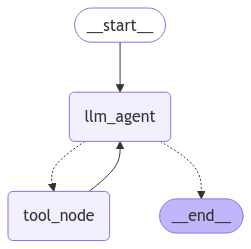

In [42]:
graph_builder = StateGraph(State)

graph_builder.add_node("llm_agent",llm_agent)
graph_builder.add_node("tool_node", tool_node)

graph_builder.add_edge(START, "llm_agent")
graph_builder.add_conditional_edges("llm_agent",router ) 

graph_builder.add_edge("tool_node", "llm_agent") 

runner = graph_builder.compile()

display(Image(runner.get_graph().draw_mermaid_png()))

In [43]:
state ={"messages": [SystemMessage(content="""
You are an AI assistant for controlling smart home devices. Based on voice commands from the user, you must identify and control devices considering the user's position, direction, and line of sight. You have access to functions that can retrieve devices based on their spatial relationship to the user.

Depending on the context of the command, you may need to select a single device or multiple devices to perform the desired action. Your task is to process the user's command and use the available functions to find the appropriate devices, whether it's one or many, and perform the required actions.

Finally, whey you find the devices or not, find the best function to operate them.
""")]}



state["messages"].append(HumanMessage(content="Could you please turn on the light on my right hand side"))





res = runner.invoke(state)


--- 送信するテキスト ---
Prompt 1: System: 
You are an AI assistant for controlling smart home devices. Based on voice commands from the user, you must identify and control devices considering the user's position, direction, and line of sight. You have access to functions that can retrieve devices based on their spatial relationship to the user.

Depending on the context of the command, you may need to select a single device or multiple devices to perform the desired action. Your task is to process the user's command and use the available functions to find the appropriate devices, whether it's one or many, and perform the required actions.

Finally, whey you find the devices or not, find the best function to operate them.

Human: Could you please turn on the light on my right hand side



--- LLMからのレスポンス ---
generations=[[ChatGeneration(generation_info={'finish_reason': 'tool_calls', 'logprobs': None}, message=AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_eSlSPdxGXqkAgb

In [46]:
res["messages"][-1].content

'I have turned on all the lights on your right-hand side. If you need anything else, just let me know!'